<a href="https://colab.research.google.com/github/SagiMeir/Simulations4Beginners/blob/Ronny/Ronny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MAIN**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks",rc={'axes.labelsize':14},palette='tab10')

x: int = 5 ** (-10)
# hbar is in J * s
hbar: float = 1.05457182 * (10**(-34))
omega: float = (50 * (10**(-3)) * (1.6 * (10**(-19))))/hbar

# omega in hrz
print("Omega (in Hz): " , omega)

# Calculation of mass
mass: float = 6.6335209 * (10**(-26))
print("Mass (in kg): " , mass)

# Energy in J
J: float = 0.5 * (x * omega) ** 2 * mass
print("\nEnergy (in Joules): " , J)

# Energy in eV
eV: float = (6.242 ** (-18)) * J
print("Energy (in eV): " , eV)

Omega (in Hz):  75860172330415.58
Mass (in kg):  6.6335209e-26

Energy (in Joules):  2.0014358253114444e-12
Energy (in eV):  9.671947074605484e-27


In [ ]:
from typing import Optional
import numpy as np
import pandas as pd
from scipy.constants import Boltzmann as BOLTZMANN
from scipy.constants import hbar

class Simulation:

    def __init__( self,
                 dt:float,
                 temp:float = 298,
                 Nsteps:int = 0,
                 R:Optional[np.ndarray] = None,
                 mass:Optional[float] = None,
                 kind:Optional[list] = None,
                 p:Optional[np.ndarray] = None,
                 F:Optional[np.ndarray] = None,
                 U:Optional[float] = None,
                 K:Optional[float] = None,
                 seed:Optional[int] = 937142,
                 ftype:str = "Harm",
                 step:int = 0,
                 printfreq:int = 1000,
                 xyzname:str = "sim.xyz",
                 fac:float = 1.0,
                 outname:str = "sim.log"
                 ) -> None:
        """
        Parameters
        ----------
        dt : float
            Simulation time step.

        temp: float
            The temperature.

        Nsteps : int, optional
            Number of steps to take. The default is 0.

        R : numpy.ndarray, optional
            Particles' positions, Natoms x 3 array. The default is None.

        mass : float, optional
            Particles' masses, Natoms x 1 array. The default is None.

        kind : list of str, optional
            Natoms x 1 list with atom type for printing. The default is None.

        p : numpy.ndarray, optional
            Particles' momenta, Natoms x 3 array. The default is None.

        F : numpy.ndarray, optional
            Particles' forces, Natoms x 3 array. The default is None.

        U : float, optional
            Potential energy . The default is None.

        K : float, optional
            Kinetic energy. The default is None.

        seed : int, optional
            Big number for reproducible random numbers. The default is 937142.

        ftype : str, optional
            String to call the force evaluation method. The default is None.

        step : INT, optional
            Current simulation step. The default is 0.

        printfreq : int, optional
            PRINT EVERY printfreq TIME STEPS. The default is 1000.

        xyzname : TYPE, optional
            DESCRIPTION. The default is "sim.xyz".

        fac : float, optional
            Factor to multiply the positions for printing. The default is 1.0.

        thermo_type: str, optional
            String to call the thermostating evaluation method. The default is None.

        outname : TYPE, optional
            DESCRIPTION. The default is "sim.log".

        Returns
        -------
        None.
        """

        #general
        self.printfreq = printfreq
        self.xyzfile = open( xyzname, 'w' )
        self.outfile = open( outname, 'w' )

        #simulation
        self.temp = temp
        self.Nsteps = Nsteps
        self.dt = dt
        self.seed = seed
        self.step = step
        self.fac = fac

        #system
        if R is not None:
            self.R = R
            self.mass = mass
            self.kind = kind
            self.Natoms = self.R.shape[0]
            # self.mass_matrix = np.array( [self.mass,]*3 ).transpose()
        else:
            self.R = np.zeros( (1,3) )
            self.mass = 1.6735575E-27 # H mass in kg as default
            self.kind = ["H"]
            self.Natoms = self.R.shape[0]
            # self.mass_matrix = np.array( [self.mass,]*3 ).transpose()
        if p is not None:
            self.p = p
            self.K = K
        else:
            self.p = np.zeros( (self.Natoms,3) )
            self.K = 0.0

        if F is not None:
            self.F = F
            self.U = U
        else:
            self.F = np.zeros( (self.Natoms,3) )
            self.U = 0.0


        #set seed
        np.random.seed( self.seed )

        #check force type
        if ( ftype == "Harm" or ftype == "Anharm"):
            self.ftype = "eval" + ftype
        else:
            raise ValueError("Wrong ftype value - use Harm or Anharm.")


    def __del__( self ) -> None:
        """
        THIS IS THE DESCTRUCTOR. NOT USUALLY NEEDED IN PYTHON.
        JUST HERE TO CLOSE THE FILES.
        Returns
        -------
        None.
        """
        self.xyzfile.close()
        self.outfile.close()

    def evalForce( self, **kwargs ) -> None:
        """
        THIS FUNCTION CALLS THE FORCE EVALUATION METHOD, BASED ON THE VALUE
        OF FTYPE, AND PASSES ALL OF THE ARGUMENTS (WHATEVER THEY ARE).
        Returns
        -------
        None. Calls the correct method based on self.ftype.
        """
        getattr(self, self.ftype)(**kwargs)

    def dumpThermo( self ) -> None:
        """
        THIS FUNCTION DUMPS THE ENERGY OF THE SYSTEM TO FILE.
        Parameters
        ----------
        R : numpy.ndarray
            Natoms x 3 array with particle coordinates.
        step : int
            Simulation time step.
        file : _io.TextIOWrapper
            File object to write to. Created using open() in main.py
        Returns
        -------
        None.
        """
        if( self.step == 0 ):
            self.outfile.write( "step K U E \n" )

        # Ensure U, K, and E are scalar values before formatting
        U_scalar = self.U.item() if isinstance(self.U, np.ndarray) else self.U
        K_scalar = self.K.item() if isinstance(self.K, np.ndarray) else self.K
        E_scalar = self.E.item() if isinstance(self.E, np.ndarray) else self.E


        self.outfile.write( str(self.step) + " " \
                          + "{:.6e}".format(K_scalar) + " " \
                          + "{:.6e}".format(U_scalar) + " " \
                          + "{:.6e}".format(E_scalar) + "\n" )

        self.outfile.flush()

    def dumpXYZ( self ) -> None:
        """
        THIS FUNCTION DUMP THE COORDINATES OF THE SYSTEM IN XYZ FORMAT TO FILE.
        Parameters
        ----------
        R : numpy.ndarray
            Natoms x 3 array with particle coordinates.
        step : int
            Simulation time step.
        file : _io.TextIOWrapper
            File object to write to. Created using open() in main.py
        Returns
        -------
        None.
        """

        self.xyzfile.write( str( self.Natoms ) + "\n")
        self.xyzfile.write( "Step " + str( self.step ) + "\n" )

        for i in range( self.Natoms ):
            self.xyzfile.write( self.kind[i] + " " + \
                              "{:.6e}".format( self.R[i,0]*self.fac ) + " " + \
                              "{:.6e}".format( self.R[i,1]*self.fac ) + " " + \
                              "{:.6e}".format( self.R[i,2]*self.fac ) + "\n" )

        self.xyzfile.flush()

    def readXYZ( self, inpname:str ) -> None:
        """
        THIS FUNCTION READS THE INITIAL COORDINATES IN XYZ FORMAT.
        Parameters
        ----------
        inpname : str
                xyz input file to read

        Returns
        -------
        None.
        """

        df = pd.read_csv( inpname, sep="\s+", skiprows=2, header=None )

        self.kind = df[ 0 ]
        self.R = df[ [1,2,3] ].to_numpy()
        self.Natoms = self.R.shape[0]


        ################################################################
        ################## NO EDITING ABOVE THIS LINE ##################
        ################################################################

    def CalcKinE( self ):
        """
        THIS FUNCTIONS EVALUATES THE KINETIC ENERGY OF THE SYSTEM.
        Returns
        -------
        None. Sets the value of self.K.
        """
        self.K = (self.p**2).sum()/(2*self.mass)

    def sampleMB( self, removeCM=True ):
        """
        THIS FUNCTIONS SAMPLES INITIAL MOMENTA FROM THE MB DISTRIBUTION.
        IT ALSO REMOVES THE COM MOMENTA, IF REQUESTED.
        Parameters
        ----------
        removeCM : bool, optional
            Remove COM velocity or not. The default is True.
        Returns
        -------
        None. Sets the value of self.p.
        """
        ################################################################
        ##################### YOUR CODE GOES HERE ######################
        ################################################################
        pass

    def evalHarm( self, omega:float ):
        """
        THIS FUNCTION EVALUATES THE POTENTIAL AND FORCE FOR A HARMONIC TRAP.
        Parameters
        ----------
        omega : float
            The frequency of the trap.
        Returns
        -------
        None. Sets the value of self.F and self.U
        """

        self.U = (self.mass/2) * (omega**2) * np.sum(self.R**2)
        self.F = (self.mass * omega**2 * self.R) * (-1)

    def VVstep( self, **kwargs ):
        """
        THIS FUNCTIONS PERFORMS ONE VELOCITY VERLET STEP.
        Returns
        -------
        None. Sets self.R, self.p.
        """

        self.p = self.p + self.dt/2 * self.F
        self.R = self.R + self.dt * (self.p/self.mass)
        self.evalForce(**kwargs)
        self.p = self.p + self.dt/2 * self.F

    def run( self, **kwargs ):
        """
        THIS FUNCTION DEFINES WHAT THE SIMULATION DOES, GIVEN AN INSTANCE OF
        THE SIMULATION CLASS. YOU WILL NEED TO:
            1. EVALUATE THE FORCES (USE evaluateForce() AND PASS A DICTIONARY
                                    WHICH ONLY CONTAINS THE PARAMETERS FOR THE
                                    FORCE EVALUATION METHOD).
            2. PROPAGATE FOR N TIME STEPS USING THE VELOCITY VERLET ALGORITHM.
            3. YOU WILL ALSO NEED TO PRINT THE COORDINATES AND ENERGIES EVERY
        PRINTFREQ TIME STEPS TO THEIR RESPECTIVE FILES, xyzfile AND outfile.
        Returns
        -------
        None.
        """

        self.evalForce(**kwargs)
        self.CalcKinE()
        self.E = self.K + self.U

        for step in range(self.Nsteps):
            self.step = step
            self.VVstep(**kwargs)
            self.CalcKinE()
            self.E = self.K + self.U

            if step % self.printfreq == 0:
              self.dumpXYZ()
              self.dumpThermo()

Simulation

In [ ]:
import numpy as np

mySim = Simulation(dt = 0.1e-15, Nsteps = 10000, printfreq = 400, step = 0)
mySim.R = np.array([[5.0, 0.0, 0.0]])
mySim.kind = ['Ar']
mySim.Natoms = 1
mySim.mass = 6.6335209e-26

mySim.p = np.random.normal(0, 1, size=(1, 3)) * np.sqrt(mySim.mass * 1.38e-23 * mySim.temp)

params = {"omega": 7.586017233041558e13}
mySim.evalForce(**params)

mySim.CalcKinE()
mySim.U = float(mySim.U)
mySim.K = float(mySim.K)
mySim.E = mySim.K + mySim.U

mySim.dumpXYZ()

mySim.run(**params)

from google.colab import files
files.download("sim.xyz")
files.download("sim.log")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# The Harmonic Oscillator

Figure 01

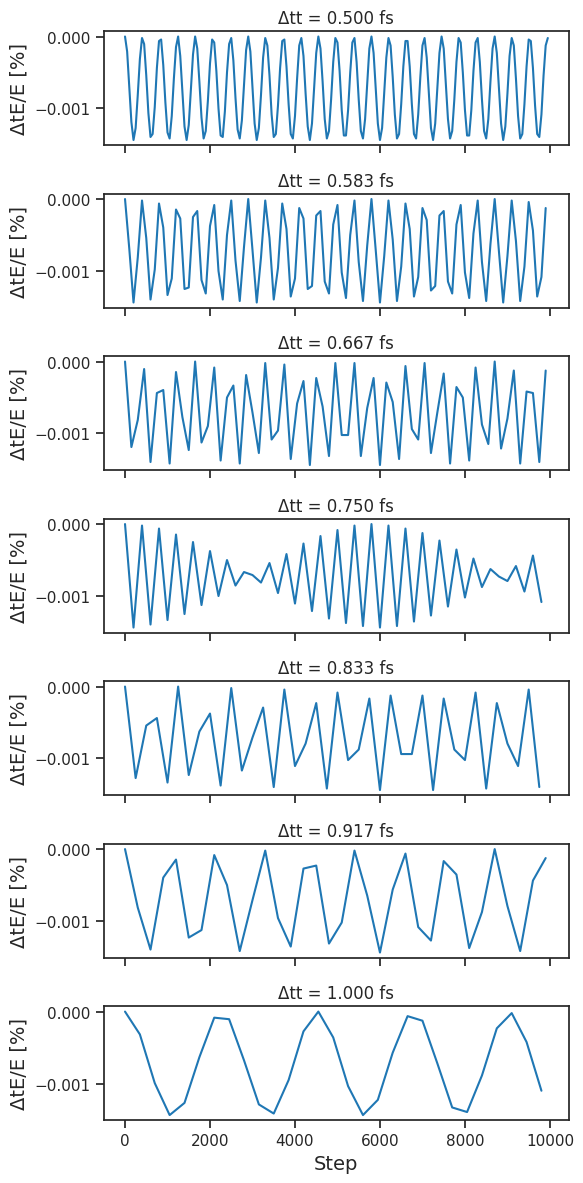

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", rc={'axes.labelsize': 14})

differences = []
beforeDt: float = 0
found: bool = False

dt_values = np.linspace(0.5e-15, 1.0e-15, 7)

for i, dt in enumerate(dt_values):
    df = pd.read_csv(f"sim_{i}.log", sep='\s+')

    energy = df["E"]
    initial_energy = energy.iloc[0]
    diff_percent = np.abs((energy - initial_energy) * 100 / initial_energy)
    max_diff = diff_percent.max()

    if max_diff >= 0.1 and not found:
        print("Max Δt with difference smaller than 0.1%:", beforeDt)
        found = True
        break

    differences.append(max_diff)
    beforeDt = dt

fig, ax = plt.subplots(len(dt_values), 1, figsize = (6, 12), sharex = True)

for i, dt in enumerate(dt_values):
    df = pd.read_csv(f"sim_{i}.log", sep='\s+')
    step = df["step"]
    energy = df["E"]
    initial_energy = energy.iloc[0]
    delta_percent = (energy - initial_energy) * 100 / initial_energy

    ax[i].plot(step, delta_percent, color = 'tab:blue', linewidth = 1.5)
    ax[i].set_title(f"\u0394tt = {dt * 1e15:.3f} fs")
    ax[i].set_ylabel("\u0394tE/E [%]")


ax[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

Largest valid Δt with < 0.1% deviation: 3.50e-13 s


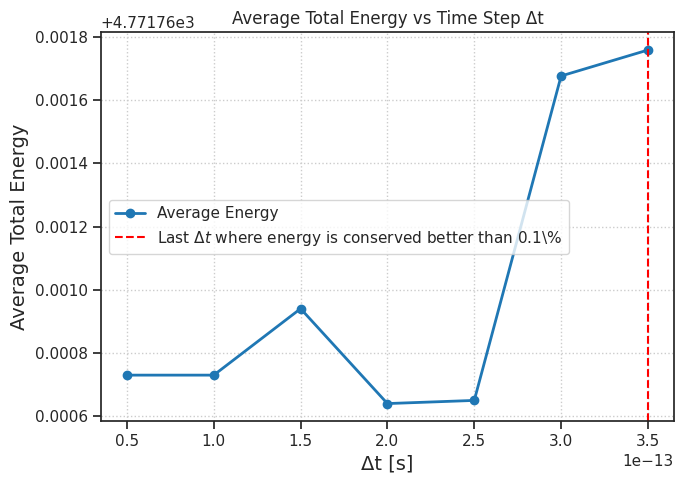

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", rc={'axes.labelsize':14}, palette='tab10')

max_allowed_error = 0.1
largest_valid_dt = None

dt_list = []
avg_energy_list = []

i = 0
while True:
    filename = f"sim_{i}.log"
    try:
        df = pd.read_csv(filename, sep=r'\s+')
    except FileNotFoundError:
        break

    steps = df["step"].values
    dt = (steps[1] - steps[0]) * 1e-15
    dt_list.append(dt)

    energy = df["E"].values
    avg_energy = np.mean(energy)
    avg_energy_list.append(avg_energy)

    deviation = np.abs((energy - energy[0]) * 100 / energy[0])
    if np.all(deviation < max_allowed_error):
        if largest_valid_dt is None or dt > largest_valid_dt:
            largest_valid_dt = dt

    i += 1

if largest_valid_dt is not None:
  print(f"Largest valid Δt with < 0.1% deviation: {largest_valid_dt:.2e} s")

plt.figure(figsize=(7, 5))
plt.plot(dt_list, avg_energy_list, marker = 'o', linewidth = 2, label = "Average Energy")
plt.axvline(3.50e-13, color = 'red', linestyle = '--', label = r"Last $\Delta t$ where energy is conserved better than 0.1\%")
plt.title("Average Total Energy vs Time Step Δt")
plt.xlabel("Δt [s]")
plt.ylabel("Average Total Energy")
plt.grid(True, linestyle = ':')
plt.legend()
plt.tight_layout()
plt.show()

Figure 02

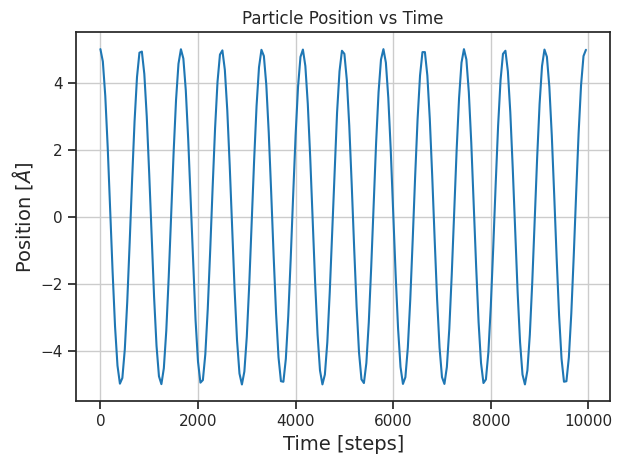

In [ ]:
import matplotlib.pyplot as plt

time = []
posX = []

with open("sim_0.xyz", "r") as f:
    while True:
        lines = [f.readline() for _ in range(3)]
        if not all(lines):
            break
        t = float(lines[1].strip().split()[1])
        x = float(lines[2].strip().split()[1])
        time.append(t)
        posX.append(x)

plt.plot(time, posX, label="Position")
plt.xlabel("Time [steps]")
plt.ylabel("Position [$\AA$]")
plt.title("Particle Position vs Time")
plt.grid(True)
plt.tight_layout()
plt.show()

Figure 03

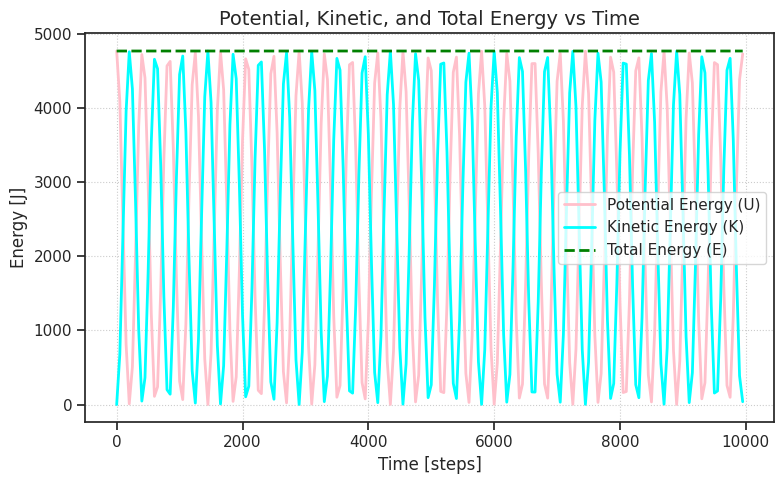

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style = "ticks",rc={'axes.labelsize':14},palette='tab10')

df = pd.read_csv("sim_0.log", sep = '\s+')

print("The ")

plt.figure(figsize = (8, 5))
plt.title("Potential, Kinetic, and Total Energy vs Time", fontsize = 14)
plt.xlabel("Time [steps]", fontsize = 12)
plt.ylabel("Energy [J]", fontsize = 12)
plt.plot(df['step'], df['U'], label = "Potential Energy (U)", color = "pink", linewidth = 2)
plt.plot(df['step'], df['K'], label="Kinetic Energy (K)", color = "cyan", linewidth = 2)
plt.plot(df['step'], df['E'], label = "Total Energy (E)", color = "green", linewidth = 2, linestyle = "--")
plt.legend(fontsize = 11)
plt.grid(True, linestyle = ":", linewidth = 0.8)
plt.tight_layout()
plt.show()

Figure 4

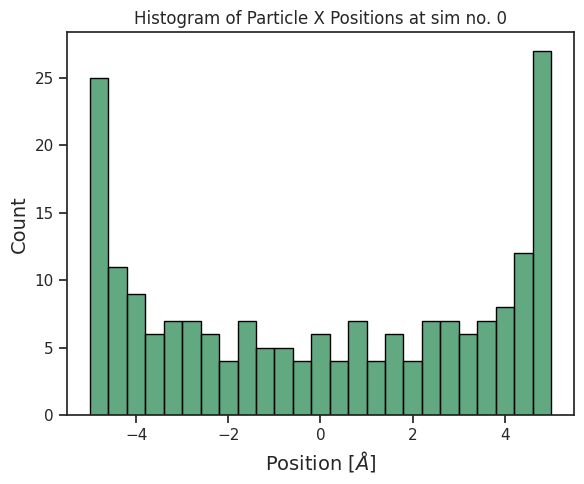

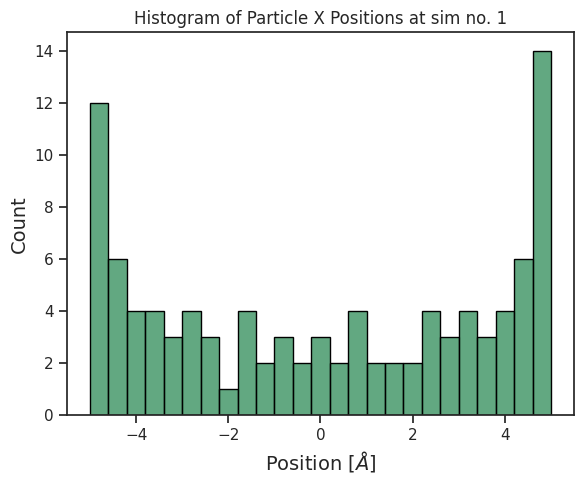

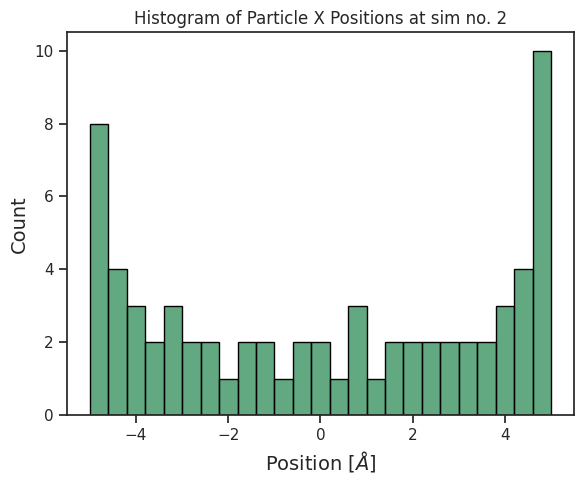

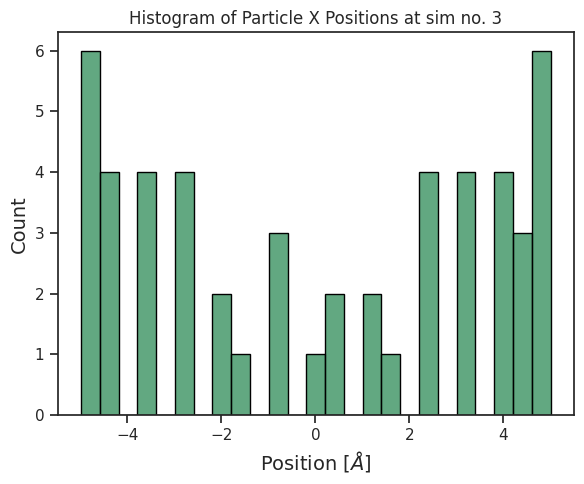

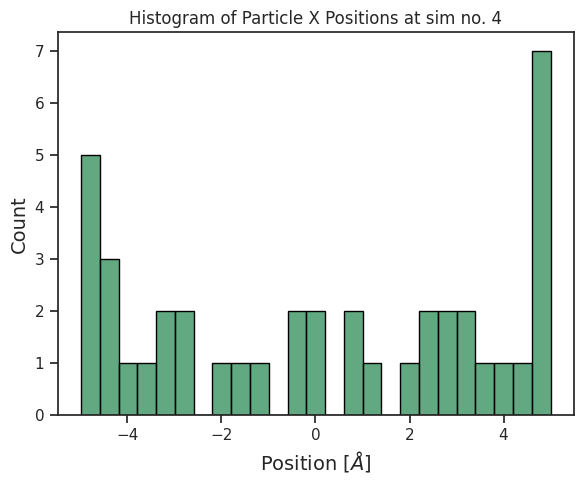

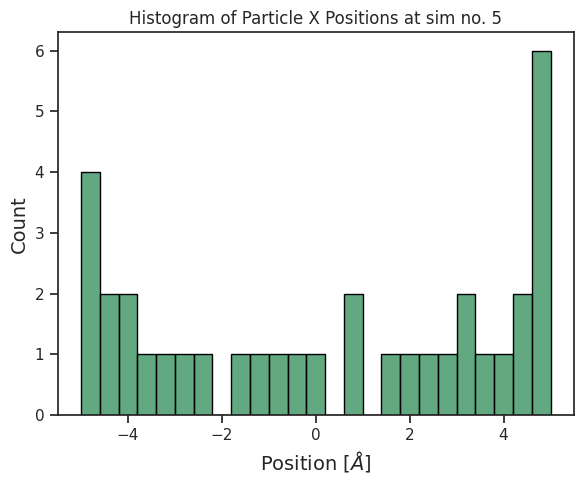

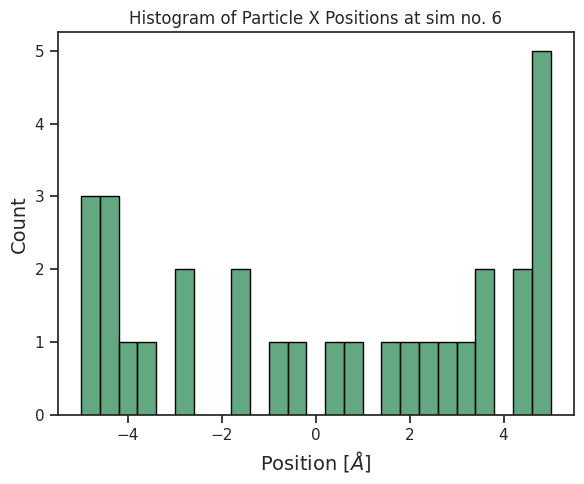

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks", rc={"axes.labelsize": 14}, palette="tab10")

for i in range(7):
  posX = []
  with open("sim_" + str(i) + ".xyz") as f:
    while True:
        f.readline()
        comment_line = f.readline()
        if not comment_line:
            break

        line = f.readline()
        if not line:
            break

        fields = line.strip().split()
        if len(fields) >= 2:
            posX.append(float(fields[1]))

  if not posX:
    raise ValueError("No positions found — check file structure.")

  plt.figure(figsize=(6, 5))
  sns.histplot(posX, bins=25, color='seagreen', edgecolor='black')
  plt.xlabel("Position [$\AA$]")
  plt.ylabel("Count")
  plt.title("Histogram of Particle X Positions at sim no. " + str(i))
  plt.tight_layout()
  plt.show()

Figure 05

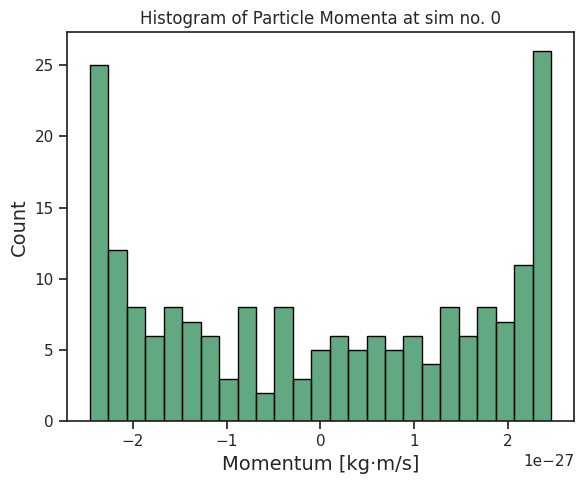

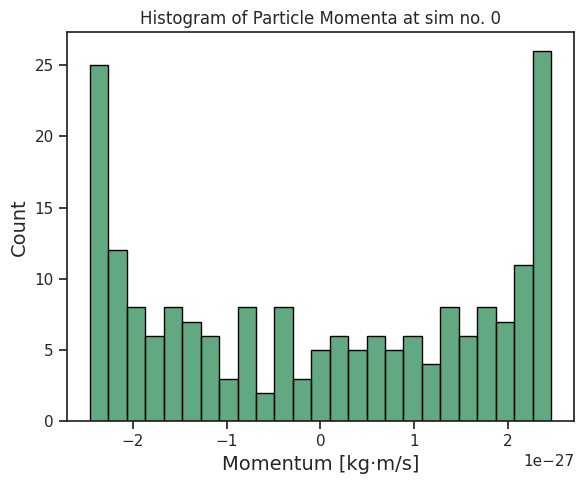

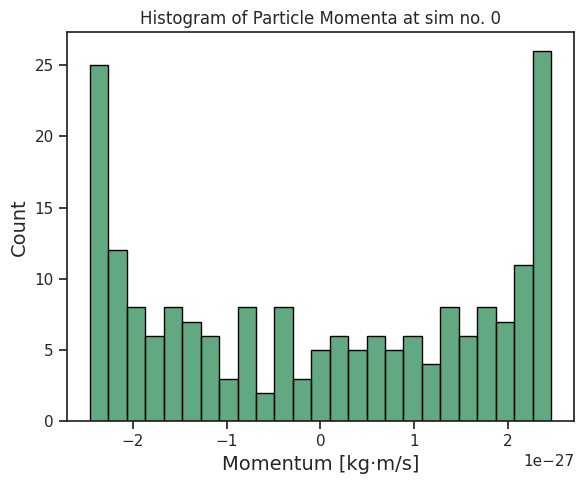

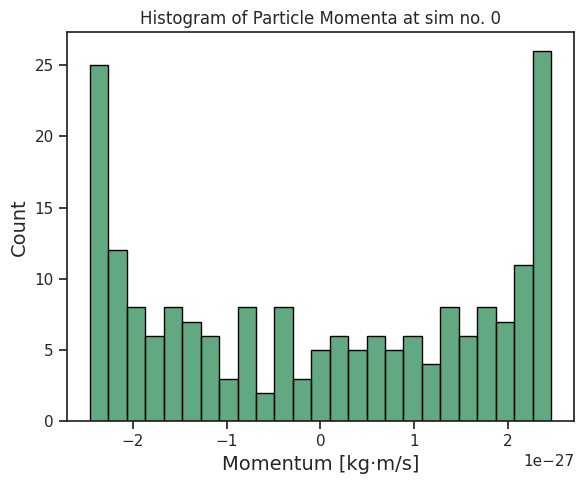

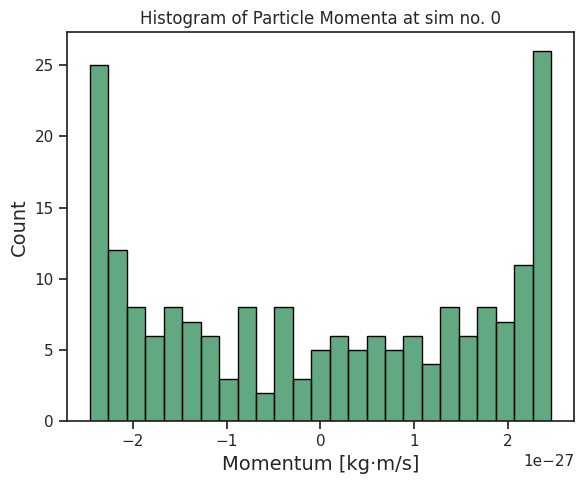

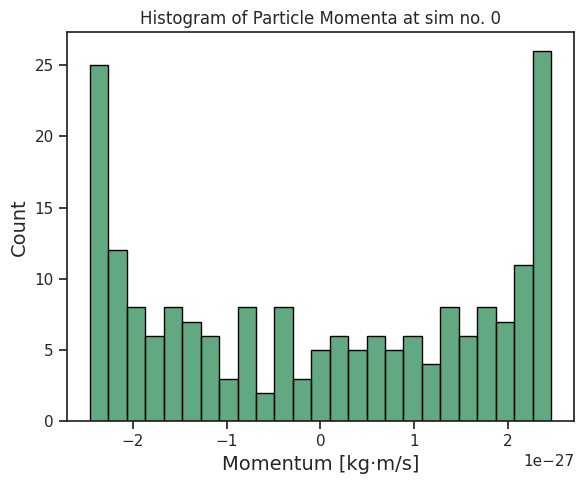

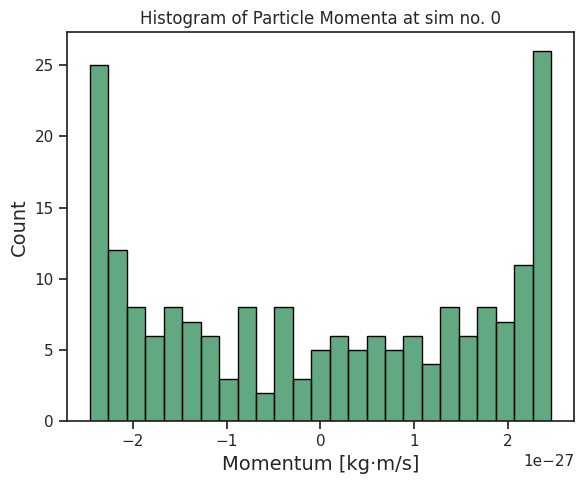

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", rc={"axes.labelsize": 14}, palette="tab10")

positions = []
times = []
mass = 6.6335209e-26

for i in range(7):
  positions = []
  times = []
  with open("sim_0.xyz", "r") as f:
    while True:
        lines = [f.readline() for _ in range(3)]
        if not all(lines):
            break
        try:
            t = float(lines[1].strip().split()[1])
            x = float(lines[2].strip().split()[1])
            times.append(t)
            positions.append(x)
        except (IndexError, ValueError):
            continue

  positions = np.array(positions)
  times = np.array(times)

  unique_mask = np.diff(times, prepend=np.nan) > 0
  positions = positions[unique_mask]
  times = times[unique_mask]

  velocities = np.gradient(positions, times)
  momenta = mass * velocities

  plt.figure(figsize=(6, 5))
  sns.histplot(momenta, bins=25, color='seagreen', edgecolor='black')
  plt.xlabel("Momentum [kg·m/s]")
  plt.ylabel("Count")
  plt.title("Histogram of Particle Momenta at sim no. 0")
  plt.tight_layout()
  plt.show()

# NVT Harmonic Oscillator

Figure 01

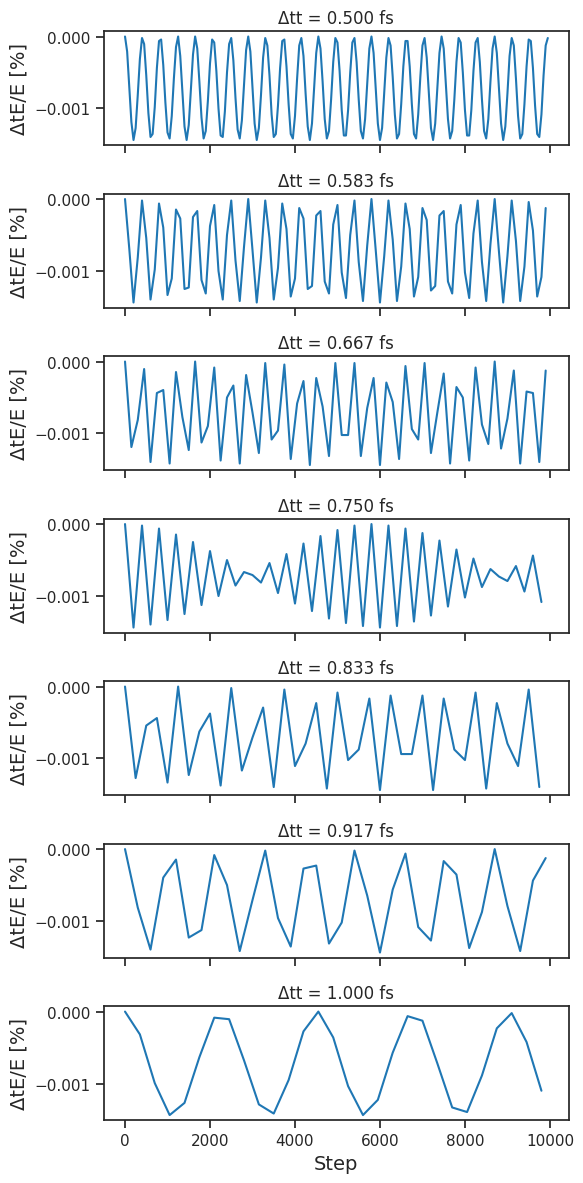

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", rc={'axes.labelsize': 14})

differences = []
beforeDt: float = 0
found: bool = False
use_thermostat: bool = False

dt_values = np.linspace(0.5e-15, 1.0e-15, 7)

for i, dt in enumerate(dt_values):
    df = pd.read_csv(f"sim_{i}.log", sep='\s+')

    energy = df["E"]
    initial_energy = energy.iloc[0]
    diff_percent = np.abs((energy - initial_energy) * 100 / initial_energy)
    max_diff = diff_percent.max()

    if max_diff >= 0.1 and not found:
        print("Max Δt with difference smaller than 0.1%:", beforeDt)
        found = True
        break

    differences.append(max_diff)
    beforeDt = dt

fig, ax = plt.subplots(len(dt_values), 1, figsize = (6, 12), sharex = True)

for i, dt in enumerate(dt_values):
    df = pd.read_csv(f"sim_{i}.log", sep='\s+')
    step = df["step"]
    energy = df["E"]
    initial_energy = energy.iloc[0]
    delta_percent = (energy - initial_energy) * 100 / initial_energy

    ax[i].plot(step, delta_percent, color = 'tab:blue', linewidth = 1.5)
    ax[i].set_title(f"\u0394tt = {dt * 1e15:.3f} fs")
    ax[i].set_ylabel("\u0394tE/E [%]")


ax[-1].set_xlabel("Step")
plt.tight_layout()
plt.show()

# Things that didn't work but seemed useful so I threw them here

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re

sns.set_theme(style="ticks", rc={"axes.labelsize": 14})

log_files = sorted(glob.glob("sim_*.log"))
plt.figure(figsize=(10, 6))
any_data = False

for fname in log_files:
    try:
        data = np.genfromtxt(fname, skip_header=1)

        if data.ndim == 1:
            data = data[None, :]

        if data.shape[1] < 4:
            continue

        time_fs = data[:, 0]
        total_energy = data[:, 3]
        time_ps = time_fs * 1e-3
        dt_fs = np.mean(np.diff(time_fs))
        dt_fs = round(dt_fs, 3)
        E0 = total_energy[0]
        percent_change = (total_energy - E0) / E0 * 100
        label = f"dt = {dt_fs} fs"
        any_data = True
        max_dev = np.max(np.abs(percent_change))
        if max_dev < 0.1:
            print(f"✔ {fname}: dt ≈ {dt_fs} fs OK (max drift = {max_dev:.5f}%)")
        else:
            print(f"✘ {fname}: dt ≈ {dt_fs} fs too large (max drift = {max_dev:.5f}%)")

    except Exception as e:
        print(f"❌ Error reading {fname}: {e}")

plt.axhline(0.1, color='gray', linestyle='--', linewidth=1)
plt.plot(time_ps, percent_change, label=label)
plt.axhline(-0.1, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Time (ps)")
plt.ylabel("Energy Change from t=0 (%)")
plt.ylim(-0.2, 0.2)
plt.title("Energy Drift vs Time for Different Time Steps")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", rc={'axes.labelsize':14})

max_allowed = 0.1
maxDt_allowed = None
maxDiff_list = []
dt_list = []

plt.figure(figsize=(8,5))

for i in range(7):
    filename = f"sim_{i}.log"
    df = pd.read_csv(filename, sep=r'\s+')
    steps = df['step'].values
    dt = np.mean(np.diff(steps))
    energy = df['E'].values
    E0 = energy[0]
    energy_percent_change = 100 * (energy - E0) / E0
    max_diff = np.max(np.abs(energy_percent_change))
    dt_list.append(dt)
    maxDiff_list.append(max_diff)

    plt.plot(df['step'], energy_percent_change, label=f'dt={dt:.2e}')
    if max_diff <= max_allowed:
        if (maxDt_allowed is None) or (dt > maxDt_allowed):
            maxDt_allowed = dt

plt.xlabel('Step')
plt.ylabel('Change in Total Energy (%)')
plt.title('Energy Conservation vs Time Step for Different dt')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

if maxDt_allowed is not None:
    print(f"Largest dt with energy conserved better than 0.1%: {maxDt_allowed:.2e}")
else:
    print("No dt found with energy conserved better than 0.1%")

In [ ]:
mySim = Simulation(dt=0.1E-15)
params = {"omega": 7.586017233041558e13}
mySim.dumpXYZ()
print(mySim.run(**params))

In [ ]:
import numpy as np

# 1. Create the simulation object
mySim = Simulation(dt=0.1e-15, Nsteps=10000, printfreq=100)

# 2. Set up a single atom manually if no input file is provided
mySim.R = np.array([[0.0, 0.0, 0.0]])       # Initial position at origin
mySim.kind = ['Ar']                         # Atom type
mySim.Natoms = 1                            # Number of atoms
mySim.mass = 6.6335209e-26                  # Argon mass in kg

# 3. Sample momenta
mySim.sampleMB()

# 4. Evaluate forces
params = {"omega": 7.586017233041558e13}
mySim.evalForce(**params)

# 5. Calculate kinetic energy and explicitly convert U and K to scalars
mySim.CalcKinE()
mySim.U = float(mySim.U)  # Explicitly convert U to float
mySim.K = float(mySim.K)  # Explicitly convert K to float
mySim.E = mySim.K + mySim.U

# 6. Dump initial XYZ coordinates
mySim.dumpXYZ()

# 7. Run the simulation — this will also dump data every `printfreq` steps
mySim.run(**params)

In [ ]:
import numpy as np
mySim = Simulation(dt=0.1e-15, Nsteps=10000, printfreq=100)
mySim.R = np.array([[0.0, 0.0, 0.0]])
mySim.Natoms = 1
mySim.kind = ["Ar"]
mySim.mass = 6.6335209e-26
mySim.sampleMB()
mySim.evalForce(omega=7.586017233041558e13)
mySim.CalcKinE()
mySim.E = float(np.sum(mySim.K) + np.sum(mySim.U))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use seaborn style for cleaner aesthetics
sns.set_theme(style="ticks", rc={'axes.labelsize': 14}, palette='tab10')

# Load data
df = pd.read_csv("SimForFigDt_4.log", sep=r'\s+')

# Plot
plt.figure(figsize=(8, 5))
plt.hist(df['posX'], bins = 25, color = 'skyblue', edgecolor = 'black')
plt.title("Histogram of Momenta", fontsize=14)
plt.xlabel(r"Momentum [$\mathrm{kg \cdot m/s}$]", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True, linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.show()


In [ ]:
time_array = np.array(time)
initial_pos_x = posX[0]
omega: float = 75860172330415.58
calc = initial_pos_x * np.cos(omega * time_array * dt)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks", rc={'axes.labelsize': 14}, palette='tab10')

posX = []
posY = []
posZ = []
time = []

df = pd.read_csv("simForFig_1.xyz")

for i in range(len(df)):
    if i % 3 == 1:
      time.append(df.iat[i, 0])

    elif i % 3 == 2:
      posX.append(df.iat[i, 0])
      posY.append(df.iat[i, 1])
      posZ.append(df.iat[i, 3])

plt.figure(figsize=(8, 5))
plt.title("Position over Time")
plt.xlabel('t [steps]')
plt.ylabel(r"pos [$\AA$]")
plt.plot(time, posX, label="Simulation", linewidth=2)
plt.plot(time, calc, color="red", linestyle='--', label="Theoretical", linewidth=2)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# and for nice looking plots:
import seaborn as sns
sns.set_theme(style="ticks",rc={'axes.labelsize':14},palette='tab10')
import math

xyz = open("simForFig_1.xyz", 'r')
# N = int(xyz.readline())
# header = xyz.readline()
posX, posY, posZ, time = ([] for i in range(4))
count = 0
for i in xyz:
    if(count % 3 == 0):
        #print(i)
        pass
    elif(count % 3 == 1):
        #print(i)
        line = i.split()
        time.append(int(line[1]))
    else:
        line = i.split()
        posX.append(float(line[1]))
        posY.append(float(line[2]))
        posZ.append(float(line[3]))
    count += 1
xyz.close()

calc = []
w = 7.596E13
dt = 0.833E-15
for i in range(len(time)):
  calc.append(posX[0] * math.cos(w * time[i] * dt))

plt.title("pos in time")
plt.xlabel('t [steps]')
plt.ylabel(r"pos [$\AA ]$")
plt.plot(time, posX, label = "the movement according the simulation")
plt.plot(time, calc, color = "red", label = "theoretical calc")
plt.legend()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
sns.set_theme(style="ticks", rc={'axes.labelsize': 14}, palette='tab10')


posX, posY, posZ, time = [], [], [], []

with open("simForFig_1.xyz", 'r') as f:
    while True:
        atom_count_line = f.readline()
        if not atom_count_line:
            break

        time_line = f.readline()
        if not time_line:
            break

        atom_line = f.readline()
        if not atom_line:
            break


        parts = time_line.strip().split()
        time.append(float(parts[1]))

        parts = atom_line.strip().split()
        posX.append(float(parts[1]))
        posY.append(float(parts[2]))
        posZ.append(float(parts[3]))

if posX[0] is not None:
    calc = [posX[0] * math.cos(omega * t * dt) for t in time]
else:
    raise ValueError("posX[0] is None. Your data is corrupted or not parsed correctly.")

plt.figure(figsize=(8, 5))
plt.plot(time, posX, label="X position", color='tab:blue', linewidth=2)

plt.figure(figsize=(8, 5))
plt.title("Position over Time")
plt.xlabel('t [steps]')
plt.ylabel(r"pos [$\AA$]")
plt.plot(time, posX, label="Simulation", linewidth=2)
plt.plot(time, calc, color="red", linestyle='--', label="Theoretical", linewidth=2)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_theme(style="ticks", rc={'axes.labelsize': 14}, palette='tab10')

# Lists for storing data
posX, posY, posZ, time = [], [], [], []

# SETTINGS
filename = "SimForFigDt_2.xyz"
atom_index = 0  # if there is more than one atom, which one to extract per frame

with open(filename, 'r') as f:
    while True:
        # Read line 1: number of atoms
        num_atoms_line = f.readline()
        if not num_atoms_line:
            break  # EOF
        try:
            num_atoms = int(num_atoms_line.strip())
        except ValueError:
            continue  # Malformed header line

        # Read line 2: time info
        time_line = f.readline()
        if not time_line:
            break
        time_parts = time_line.strip().split()
        try:
            t = float(time_parts[1])
        except (IndexError, ValueError):
            continue  # Skip bad time line

        # Read next `num_atoms` lines (position lines)
        atom_lines = [f.readline() for _ in range(num_atoms)]
        if len(atom_lines) < atom_index + 1:
            continue  # Not enough atoms in this frame

        pos_parts = atom_lines[atom_index].strip().split()
        try:
            x = float(pos_parts[1])
            y = float(pos_parts[2])
            z = float(pos_parts[3])
        except (IndexError, ValueError):
            continue  # Bad atom line

        # Store valid frame data
        time.append(t)
        posX.append(x)
        posY.append(y)
        posZ.append(z)

# Final check before calculation
if not posX:
    raise ValueError("posX is empty — file read failed or format is wrong")

# Constants for theoretical motion
omega = 7.596e13
dt = 0.833e-15
calc = [posX[0] * math.cos(omega * t * dt) for t in time]

# Plot
plt.figure(figsize=(8, 5))
plt.title("Position over Time")
plt.xlabel('t [steps]')
plt.ylabel(r"pos [$\AA$]")
plt.plot(time, posX, label="Simulation", linewidth=2)
plt.plot(time, calc, color="red", linestyle='--', label="Theoretical", linewidth=2)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_theme(style="ticks", rc={'axes.labelsize': 14}, palette='tab10')

posX, posY, posZ, time = [], [], [], []

with open("simForFig_1.xyz", 'r') as f:
    while True:
        atom_count_line = f.readline()
        if not atom_count_line:
            break

        time_line = f.readline()
        if not time_line:
            break

        atom_line = f.readline()
        if not atom_line:
            break

        try:
            parts_time = time_line.strip().split()
            parts_pos = atom_line.strip().split()

            if len(parts_time) >= 2 and len(parts_pos) >= 4:
                t = float(parts_time[1])
                x = float(parts_pos[1])
                y = float(parts_pos[2])
                z = float(parts_pos[3])

                time.append(t)
                posX.append(x)
                posY.append(y)
                posZ.append(z)

        except (IndexError, ValueError):
            continue

if not posX:
    raise ValueError("posX is empty — no valid data was read.")
if posX[0] is None:
    raise ValueError("posX[0] is None — check your input parsing.")

omega =  75860172330415.58
dt = 8.333333333333334e-16

calc = [posX[0] * math.cos(omega * t * dt) for t in time]

plt.figure(figsize=(8, 5))
plt.title("Position over Time")
plt.xlabel('t [steps]')
plt.ylabel(r"pos [$\AA$]")
plt.plot(time, posX, label="Simulation", linewidth=2)
plt.plot(time, calc, color="red", linestyle='--', label="Theoretical", linewidth=2)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
with open("SimForFigDt_2.xyz", "r") as f:
    while True:
        atom_count = f.readline()
        if not atom_count:
            break  # End of file

        time_line = f.readline()
        atom_line = f.readline()

        if not time_line or not atom_line:
            break  # Incomplete frame

        try:
            t = float(time_line.strip().split()[1])
            x = float(atom_line.strip().split()[1])
            time.append(t)
            posX.append(x)
        except:
            continue

In [ ]:
import numpy as np

# 1. Create the simulation object
mySim = Simulation(dt=0.1e-15, Nsteps=10000, printfreq=100)

# 2. Set up a single atom manually if no input file is provided
mySim.R = np.array([[0.0, 0.0, 0.0]])       # Initial position at origin
mySim.kind = ['Ar']                         # Atom type
mySim.Natoms = 1                            # Number of atoms
mySim.mass = 6.6335209e-26                  # Argon mass in kg

# 3. Sample momenta
mySim.sampleMB()

# 4. Evaluate forces
params = {"omega": 7.586017233041558e13}
mySim.evalForce(**params)

# 5. Calculate kinetic energy and total energy.
mySim.CalcKinE()

# mySim.U is a (3,) array from evalHarm due to the use of built-in sum().
# Sum its elements to get the total potential energy as a scalar.
# mySim.K should already be a scalar from CalcKinE.
mySim.U = np.sum(mySim.U)
# Ensure K is scalar, though CalcKinE should produce a scalar for 1 atom
mySim.K = mySim.K.item() if isinstance(mySim.K, np.ndarray) else mySim.K

mySim.E = mySim.K + mySim.U

# 6. Dump initial XYZ coordinates
mySim.dumpXYZ()

# 7. Run the simulation — this will also dump data every `printfreq` steps
mySim.run(**params)